In [1]:
import os 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import glob
from scipy.interpolate import interp1d
sns.set_theme(style="darkgrid")

In [34]:
# Select the drone
drone = 'MAVIC' # 'M300' or 'MAVIC'

In [35]:
basefolder = '/home/agostino/Desktop/droni/volo_20251103_arluno/' # Adjust it according to the machine.
basefolder = '/home/agostino/Desktop/droni/volo_20251211_jrc/'

path_to_fr = basefolder+'data/'+drone+'/FlightRecords/'

listoffiles_fr = sorted(glob.glob(path_to_fr+'*csv'))
listoffiles_fr # It contains all files the selected directory.

['/home/agostino/Desktop/droni/volo_20251211_jrc/data/MAVIC/FlightRecords/DJIFlightRecord_2025-12-11_[10-31-14].csv',
 '/home/agostino/Desktop/droni/volo_20251211_jrc/data/MAVIC/FlightRecords/DJIFlightRecord_2025-12-11_[10-55-29].csv',
 '/home/agostino/Desktop/droni/volo_20251211_jrc/data/MAVIC/FlightRecords/DJIFlightRecord_2025-12-11_[14-42-25].csv',
 '/home/agostino/Desktop/droni/volo_20251211_jrc/data/MAVIC/FlightRecords/DJIFlightRecord_2025-12-11_[15-04-08].csv',
 '/home/agostino/Desktop/droni/volo_20251211_jrc/data/MAVIC/FlightRecords/DJIFlightRecord_2025-12-11_[16-00-15].csv']

In [36]:
# Read all files in the listoffiles_fr

df = pd.concat((pd.read_csv(f) for f in listoffiles_fr), ignore_index=True)
    
# Select only relevant columns
fr_df = df[['CUSTOM.dateTime', 'OSD.latitude', 'OSD.longitude', 'OSD.height', 'OSD.xSpeed', 'OSD.ySpeed', 
            'OSD.zSpeed', 'OSD.yaw', 'OSD.pitch', 'OSD.roll']].copy()

/tmp/ipykernel_378009/2520964464.py:3: DtypeWarning: Columns (106) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.concat((pd.read_csv(f) for f in listoffiles_fr), ignore_index=True)


In [37]:
# Convert time info in UTC datetime.
fr_df['CUSTOM.dateTime_dt'] = pd.to_datetime(fr_df['CUSTOM.dateTime'], format='ISO8601',utc=True)

# Filter sampling errors.
median_time = fr_df['CUSTOM.dateTime_dt'].median()
i_to_drop = fr_df.loc[(fr_df['CUSTOM.dateTime_dt'] > median_time+pd.Timedelta(1,'day')) | (fr_df['CUSTOM.dateTime_dt'] < median_time-pd.Timedelta(1,'day'))].index
print(f"Dropping {len(i_to_drop)} rows with datetime errors.")
fr_df.drop(axis=0, index=i_to_drop,inplace=True)
fr_df

Dropping 0 rows with datetime errors.


,CUSTOM.dateTime,OSD.latitude,OSD.longitude,OSD.height,OSD.xSpeed,OSD.ySpeed,OSD.zSpeed,OSD.yaw,OSD.pitch,OSD.roll,CUSTOM.dateTime_dt
0,2025-12-11T09:31:14.428Z,45.814627,8.635693,0.0,0.0,0.0,0.0,-82.2,2.3,-0.3,2025-12-11 09:31:14.428000+00:00
1,2025-12-11T09:31:14.539Z,45.814627,8.635693,0.0,0.0,0.0,0.0,-82.2,2.3,-0.3,2025-12-11 09:31:14.539000+00:00
2,2025-12-11T09:31:14.644Z,45.814627,8.635693,0.0,0.0,0.0,0.0,-82.2,2.3,-0.3,2025-12-11 09:31:14.644000+00:00
3,2025-12-11T09:31:14.746Z,45.814627,8.635693,0.0,0.0,0.0,0.0,-82.2,2.3,-0.3,2025-12-11 09:31:14.746000+00:00
4,2025-12-11T09:31:14.854Z,45.814627,8.635693,0.0,0.0,0.0,0.0,-82.2,2.3,-0.4,2025-12-11 09:31:14.854000+00:00
...,...,...,...,...,...,...,...,...,...,...,...
56276,2025-12-11T15:13:57.170Z,45.814635,8.635612,-0.3,0.0,0.0,0.0,-59.0,2.2,0.0,2025-12-11 15:13:57.170000+00:00
56277,2025-12-11T15:13:57.276Z,45.814635,8.635612,-0.3,0.0,0.0,0.0,-59.0,2.2,0.0,2025-12-11 15:13:57.276000+00:00
56278,2025-12-11T15:13:57.385Z,45.814635,8.635612,-0.3,0.0,0.0,0.0,-59.0,2.2,0.0,2025-12-11 15:13:57.385000+00:00
56279,2025-12-11T15:13:57.493Z,45.814635,8.635612,-0.3,0.0,0.0,0.0,-59.0,2.2,0.0,2025-12-11 15:13:57.493000+00:00


In [38]:
# Read the trisonica and imet data
path_to_tris = basefolder + 'data/trisonica/'
path_to_imet = basefolder + 'data/imet/'

listoffiles_tris = sorted(glob.glob(path_to_tris+'*csv'))
listoffiles_tris
df_tris = pd.concat((pd.read_csv(f,sep=';',header=8,skipinitialspace=True) for f in listoffiles_tris), ignore_index=True)
#df_tris['Time (UTC) dt'] = pd.to_datetime('2025-11-03 '+df_tris['Time (UTC)']) 
df_tris['Time (UTC) dt'] = pd.to_datetime('2025-12-11 '+df_tris['Time (UTC)']) 
time_tris = df_tris['Time (UTC) dt'].values
print(df_tris.columns)

#listoffiles_imet = sorted(glob.glob(path_to_imet+'*csv')) # 20251103_arluno
listoffiles_imet = sorted(glob.glob(path_to_imet+'imet*csv')) # 20251211_jrc
print(listoffiles_imet[0]) # We only have one file!
df_imet_orig = pd.read_csv(listoffiles_imet[0])
print(df_imet_orig.columns)
df_imet = df_imet_orig[['XQ-iMet-XQ Pressure', 'XQ-iMet-XQ Air Temperature', 'XQ-iMet-XQ Humidity',
                        'XQ-iMet-XQ Humidity Temp', 'XQ-iMet-XQ Date', 'XQ-iMet-XQ Time', 'XQ-iMet-XQ Longitude', 
                        'XQ-iMet-XQ Latitude', 'XQ-iMet-XQ Altitude']].copy()

Index(['Time (UTC)', 'SKH1_70727633.pr', 'SKH1_70727633.bat',
       'SKH1_70727633.temp', 'SKH1_70727633.rh', 'SKH1_70727633.lat',
       'SKH1_70727633.lon', 'SKH1_70727633.alt', 'C.wspd', 'C.wdir', 'C.windU',
       'C.windV', 'C.windW', 'C.temp', 'C.rh', 'C.pr', 'C.pitch', 'C.roll',
       'C.heading', 'Time (UTC) dt'],
      dtype='object')
/home/agostino/Desktop/droni/volo_20251211_jrc/data/imet/imet_20251211.csv
Index(['Time', 'COM Elapse', '0-Pressure', '0-Pressure Temperature',
       '0-Humidity', '0-Humidity Temperature', '1-EE03 Humidity',
       '1-EE03 Humidity Temperature', '2-Sensor Temperature',
       '2-Object Temperature', '3-GPS Latitude', '3-GPS Longitude',
       '3-GPS Altitude', '3-GPS Sat Count', '4-HTU21D Humidity',
       '4-HTU21D Humidity Temperature', '5-NTC Temperature A',
       '5-NTC Resistance A', '6-Hanwei CO ppm', '6-Hanwei CO SUP VDC',
       '6-Hanwei CO VDC ', '7-Hanwei CH4 ppm', '7-Hanwei CH4 SUP VDC',
       '7-Hanwei CH4 VDC ', '8-IST HYT 271

In [ ]:
# Read the JRC tower data.



Dropping 0 rows with datetime errors.


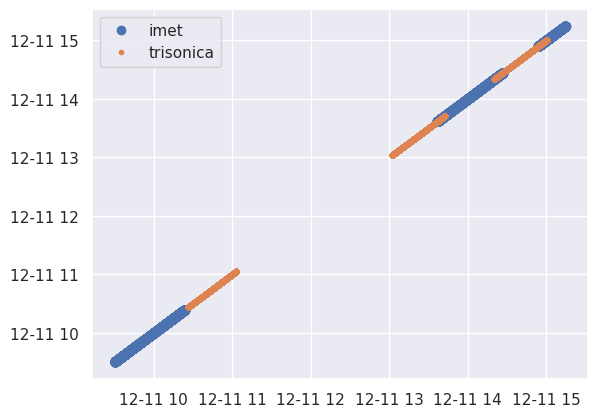

In [43]:
# Convert imet time in a pd.datetime [UTC]
df_imet['Time (UTC) dt'] = pd.to_datetime(df_imet['XQ-iMet-XQ Date']+' '+df_imet['XQ-iMet-XQ Time'],format='%Y/%m/%d %H:%M:%S')

# Filter sampling errors.
median_time = df_imet['Time (UTC) dt'].median()
i_to_drop = df_imet.loc[(df_imet['Time (UTC) dt'] > median_time+pd.Timedelta(1,'day')) | (df_imet['Time (UTC) dt'] < median_time-pd.Timedelta(1,'day'))].index
print(f"Dropping {len(i_to_drop)} rows with datetime errors.")
df_imet.drop(axis=0, index=i_to_drop,inplace=True)

time_imet = df_imet['Time (UTC) dt'].values

# Check when IMET and Trisonica where turned on to see whether there are simultaneous flights or not.
plt.plot(time_imet,time_imet,'o',label='imet')
plt.plot(time_tris,time_tris,'.',label='trisonica')
plt.legend()

(-1.0, 1.0)

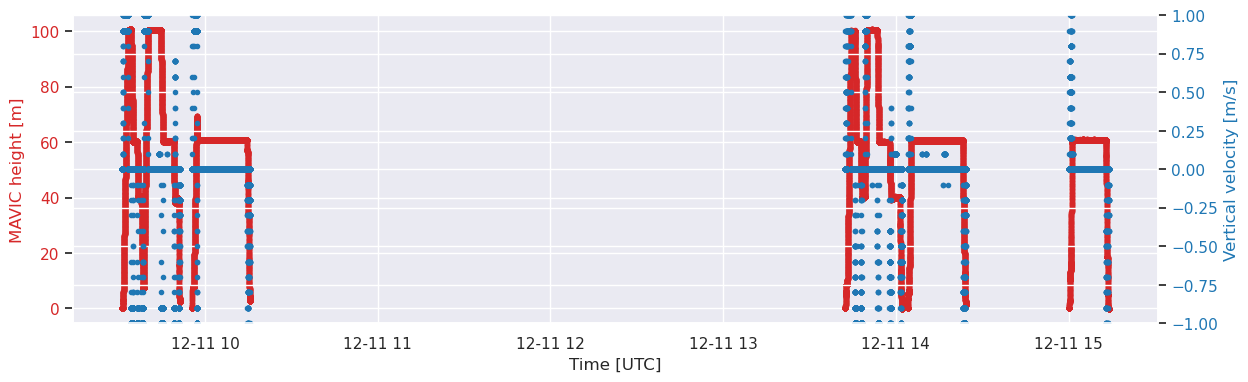

In [44]:
# Plot a time series of the height of the drone for all files considered, together with the vertical speed.

fig,ax1=plt.subplots(1,1,figsize=(14,4))

plt.xlabel('Time [UTC]')
plt.ylabel(drone + ' height [m]')

color = 'tab:red'
ax1.set_xlabel('Time [UTC]')
ax1.set_ylabel(drone+' height [m]', color=color)
ax1.plot(fr_df['CUSTOM.dateTime_dt'],fr_df['OSD.height'],'.',color=color)
ax1.tick_params(axis='y', labelcolor=color)
             
ax2 = ax1.twinx() 

color = 'tab:blue'
ax2.set_ylabel('Vertical velocity [m/s]', color=color) # it is positive going down!
ax2.plot(fr_df['CUSTOM.dateTime_dt'],-fr_df['OSD.zSpeed'],'.',color=color)
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylim([-1,1])

# Select a time window to zoom in or comment to look at the full timeseries
#ax1.set_xlim([np.datetime64('2025-11-03 10:30:00'),np.datetime64('2025-11-03 11:15:00')]) # three hoverings
#ax1.set_xlim([np.datetime64('2025-11-03 14:00:00'),np.datetime64('2025-11-03 14:10:00')]) # a vertical profile

(np.float64(20433.395833333332), np.float64(20433.416666666668))

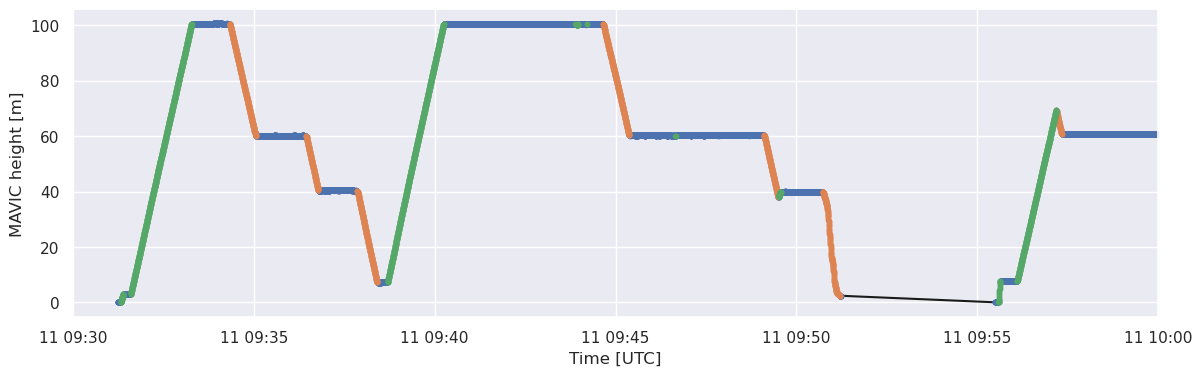

In [66]:
# We can identify the following cathegories: ascent, descent, hovering
# ascent: zSpeed < -0.01 m/s
# descent: zSpeed > 0.01 m/s
# hovering in all other cases

fig,ax1=plt.subplots(1,1,figsize=(14,4))

plt.xlabel('Time [UTC]')
plt.ylabel(drone + ' height [m]')

time = fr_df['CUSTOM.dateTime_dt'].values
height = fr_df['OSD.height'].values
zs = -fr_df['OSD.zSpeed'].values # We change sign because it is positive going down.

ax1.set_xlabel('Time [UTC]')
ax1.set_ylabel(drone+' height [m]')
ax1.plot(time,height,'-k')
thresh = 0.03 # m/s
ax1.plot(time[np.abs(zs)<thresh],height[np.abs(zs)<thresh],'.')
ax1.plot(time[zs<-thresh],height[zs<-thresh],'.')
ax1.plot(time[zs>thresh],height[zs>thresh],'.')
ax1.tick_params(axis='y')
    
# Select a time window to zoom in or comment to look at the full timeseries
#ax1.set_xlim([np.datetime64('2025-11-03 10:30:00'),np.datetime64('2025-11-03 11:15:00')]) # three hoverings
#ax1.set_xlim([np.datetime64('2025-11-03 14:20:00'),np.datetime64('2025-11-03 14:40:00')]) # free
#ax1.set_xlim([np.datetime64('2025-11-03 14:00:00'),np.datetime64('2025-11-03 14:10:00')]) # a vertical profile
ax1.set_xlim([np.datetime64('2025-12-11 09:30:00'),np.datetime64('2025-12-11 10:00:00')]) # free

In [58]:
# Profiles of the vertical profiles

# 20251103_arluno

#1
start = np.datetime64('2025-11-03 14:01:34')
end = np.datetime64('2025-11-03 14:08:50')
label_title = 'profile1'

#2
start = np.datetime64('2025-11-03 14:08:50')
end = np.datetime64('2025-11-03 14:13:40')
label_title = 'profile2'

#3
start = np.datetime64('2025-11-03 14:38:35')
end = np.datetime64('2025-11-03 14:45:38')
label_title = 'profile3'

#4
start = np.datetime64('2025-11-03 14:46:45')
end = np.datetime64('2025-11-03 14:53:25')
label_title = 'profile4'
"""
#5
start = np.datetime64('2025-11-03 14:53:25')
end = np.datetime64('2025-11-03 14:58:30')
label_title = 'profile5'
"""

# 20251211_jrc, note that here the two drones where not flying at the same time!

start = np.datetime64('2025-12-11 09:31:00')
end = np.datetime64('2025-12-11 09:38:00')
label_title = 'P1.1.mavic'

#start = np.datetime64('2025-12-11 10:30:20')
#end = np.datetime64('2025-12-11 10:38:40')
#label_title = 'P1.1.m300'

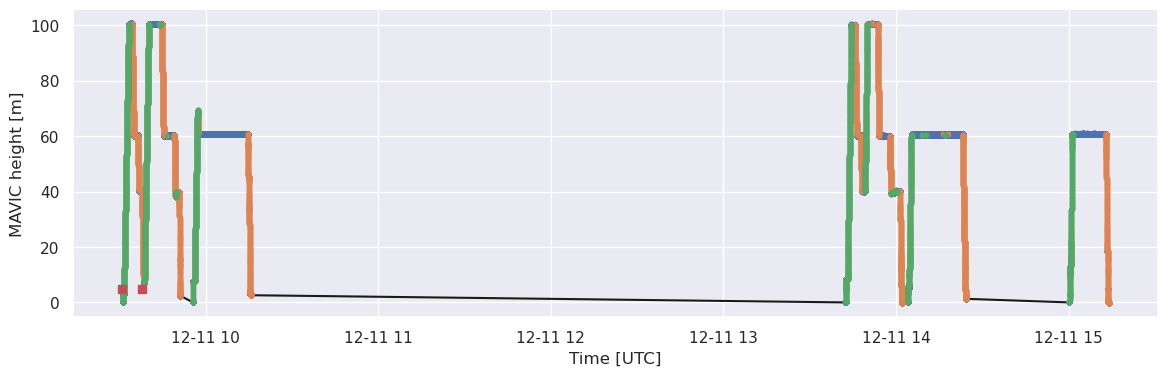

In [59]:
# Same figure as before with the start and end overlaid.

fig,ax1=plt.subplots(1,1,figsize=(14,4))

plt.xlabel('Time [UTC]')
plt.ylabel(drone + ' height [m]')

time = fr_df['CUSTOM.dateTime_dt'].values
height = fr_df['OSD.height'].values
zs = -fr_df['OSD.zSpeed'].values # We change sign because it is positive going down.

ax1.set_xlabel('Time [UTC]')
ax1.set_ylabel(drone+' height [m]')
ax1.plot(time,height,'-k')
thresh = 0.03 # m/s
ax1.plot(time[np.abs(zs)<thresh],height[np.abs(zs)<thresh],'.')
ax1.plot(time[zs<-thresh],height[zs<-thresh],'.')
ax1.plot(time[zs>thresh],height[zs>thresh],'.')
ax1.tick_params(axis='y')

ax1.plot([start,end],[5,5],'rs')

In [60]:
# Extract data only in the time frame of interest

df_subset = fr_df[(time>=start) & (time<=end)]
df_subset_tris = df_tris[(time_tris>=start) & (time_tris<=end)]
df_subset_imet = df_imet[(time_imet>=start) & (time_imet<=end)]

In [64]:
# Profiles of wind speed, air temperature and RH.
# Ascending, descending and hovering.

reference_date = '2025-11-03' # 20251103_arluno
reference_date = '2025-12-11' # 20251211_jrc

height_fr_s = df_subset['OSD.height'].values
zs_fr_s = df_subset['OSD.zSpeed'].values
time_fr_s = (df_subset['CUSTOM.dateTime_dt'] - pd.to_datetime(reference_date,utc=True)) // pd.Timedelta('1s')
# Note that we are downgrading to 1 s frequency!!!!!!!!!!!!!
f_h = interp1d(time_fr_s,height_fr_s,fill_value='extrapolate')
f_zs = interp1d(time_fr_s,zs_fr_s,fill_value='extrapolate')

# Interpolate the OSD.height and OSD.zSpeed on the trisonica time axis
time_tris_s = (df_subset_tris['Time (UTC) dt'] - pd.to_datetime(reference_date)) // pd.Timedelta('1s')
height_tris_s = f_h(time_tris_s)
zs_tris_s = -f_zs(time_tris_s) # Make the vertical velocity positive going up!

# Interpolate the OSD.height and OSD.zSpeed on the imet time axis
time_imet_s = (df_subset_imet['Time (UTC) dt'] - pd.to_datetime(reference_date)) // pd.Timedelta('1s')
height_imet_s = f_h(time_imet_s)
zs_imet_s = -f_zs(time_imet_s) # Make the vertical velocity positive going up!

/home/agostino/miniconda3/envs/uas/lib/python3.14/site-packages/scipy/interpolate/_interpolate.py:497: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/home/agostino/miniconda3/envs/uas/lib/python3.14/site-packages/scipy/interpolate/_interpolate.py:497: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]


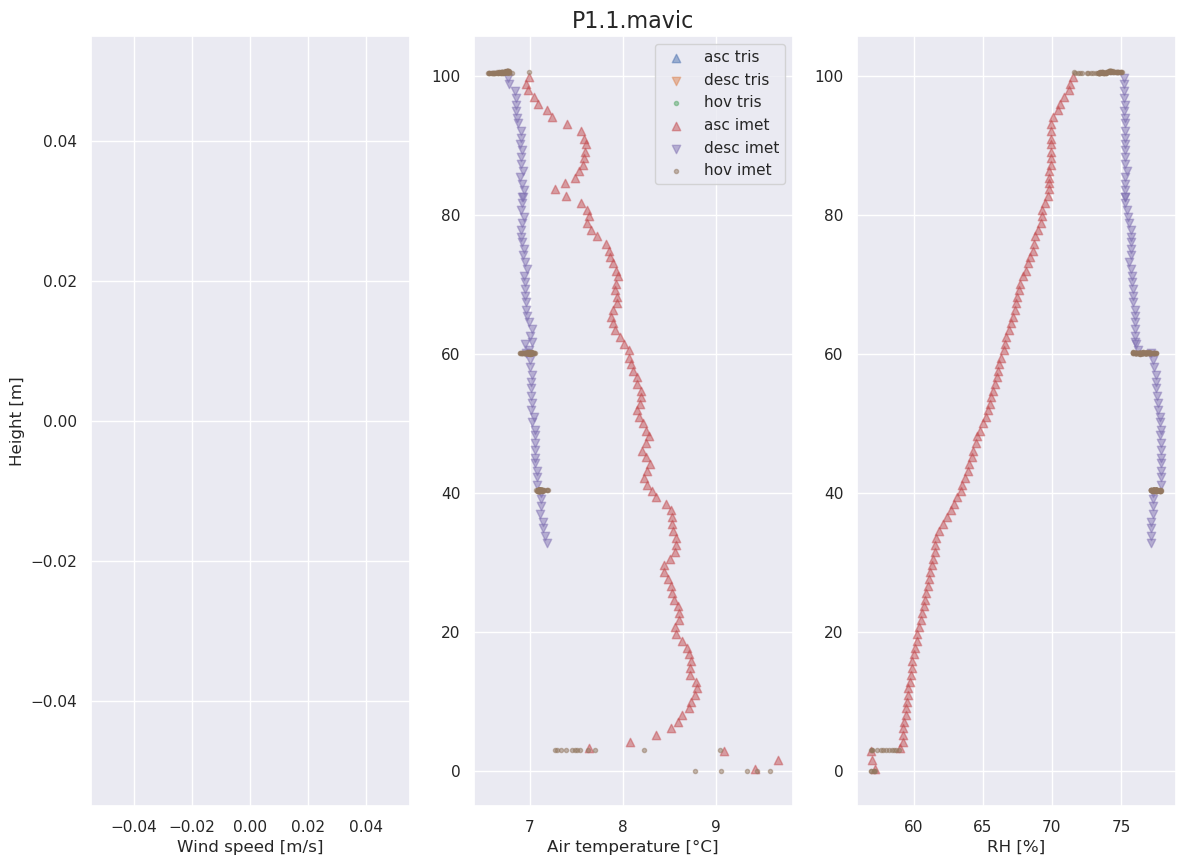

In [65]:
fig,ax=plt.subplots(1,3,figsize=(14,10))

plt.xlabel('Time [UTC]')

x = df_subset_tris['C.wspd'].values
y = height_tris_s
y_i = height_imet_s

zst = 0.2 # m/s, threshold for vertical velocity

ax[0].set_xlabel('Wind speed [m/s]')
ax[0].set_ylabel('Height [m]')
ax[0].scatter(x[zs_tris_s>zst],y[zs_tris_s>zst],marker='^',alpha=.5) # ascending
ax[0].scatter(x[zs_tris_s<-zst],y[zs_tris_s<-zst],marker='v',alpha=.5) # descending
ax[0].scatter(x[np.abs(zs_tris_s)<zst],y[np.abs(zs_tris_s)<zst],marker='.',alpha=.5) # hovering

x = df_subset_tris['SKH1_70727633.temp'].values
x_i = df_subset_imet['XQ-iMet-XQ Air Temperature'].values

ax[1].set_title(label_title,fontsize=16)
ax[1].set_xlabel('Air temperature [°C]')
ax[1].scatter(x[zs_tris_s>zst],y[zs_tris_s>zst],marker='^',alpha=.5,label='asc tris') # ascending
ax[1].scatter(x[zs_tris_s<-zst],y[zs_tris_s<-zst],marker='v',alpha=.5,label='desc tris') # descending
ax[1].scatter(x[np.abs(zs_tris_s)<zst],y[np.abs(zs_tris_s)<zst],marker='.',alpha=.5,label='hov tris') # hovering
ax[1].scatter(x_i[zs_imet_s>zst],y_i[zs_imet_s>zst],marker='^',alpha=.5,label='asc imet') # ascending
ax[1].scatter(x_i[zs_imet_s<-zst],y_i[zs_imet_s<-zst],marker='v',alpha=.5,label='desc imet') # descending
ax[1].scatter(x_i[np.abs(zs_imet_s)<zst],y_i[np.abs(zs_imet_s)<zst],marker='.',alpha=.5,label='hov imet') # hovering
ax[1].legend()

x = df_subset_tris['SKH1_70727633.rh'].values
x_i = df_subset_imet['XQ-iMet-XQ Humidity'].values

ax[2].set_xlabel('RH [%]')
ax[2].scatter(x[zs_tris_s>0.2],y[zs_tris_s>0.2],marker='^',alpha=.5) # ascending
ax[2].scatter(x[zs_tris_s<-0.2],y[zs_tris_s<-0.2],marker='v',alpha=.5) # descending
ax[2].scatter(x[np.abs(zs_tris_s)<0.2],y[np.abs(zs_tris_s)<0.2],marker='.',alpha=.5) # hovering
ax[2].scatter(x_i[zs_imet_s>0.2],y_i[zs_imet_s>0.2],marker='^',alpha=.5) # ascending
ax[2].scatter(x_i[zs_imet_s<-0.2],y_i[zs_imet_s<-0.2],marker='v',alpha=.5) # descending
ax[2].scatter(x_i[np.abs(zs_imet_s)<0.2],y_i[np.abs(zs_imet_s)<0.2],marker='.',alpha=.5) # hovering

plt.savefig('vertical_'+label_title+'.png',bbox_inches='tight')

In [107]:
# Timeseries of the wind speed and direction, air temperature and humidity during the hoverings.

#1 @ 3m
start = np.datetime64('2025-11-03 10:34:18')
end = np.datetime64('2025-11-03 10:43:10')
label_title = 'hovering3m'

#2 @ 50m
start = np.datetime64('2025-11-03 10:47:55')
end = np.datetime64('2025-11-03 10:55:10')
label_title = 'hovering50m'

#3 @ 8m
start = np.datetime64('2025-11-03 11:00:55')
end = np.datetime64('2025-11-03 11:09:50')
label_title = 'hovering8m'

#4 @ 20m
start = np.datetime64('2025-11-03 13:35:10')
end = np.datetime64('2025-11-03 13:50:00')
label_title = 'hovering20m'
""" # no imet data for this hovering
#5 @ 80m # for M300 only
start = np.datetime64('2025-11-03 14:21:30')
end = np.datetime64('2025-11-03 14:32:10')
label_title = 'hovering80m'
"""

In [108]:
# Extract data only in the time frame of interest

df_subset = fr_df[(time>=start) & (time<=end)]
df_subset_tris = df_tris[(time_tris>=start) & (time_tris<=end)]
df_subset_imet = df_imet[(time_imet>=start) & (time_imet<=end)]

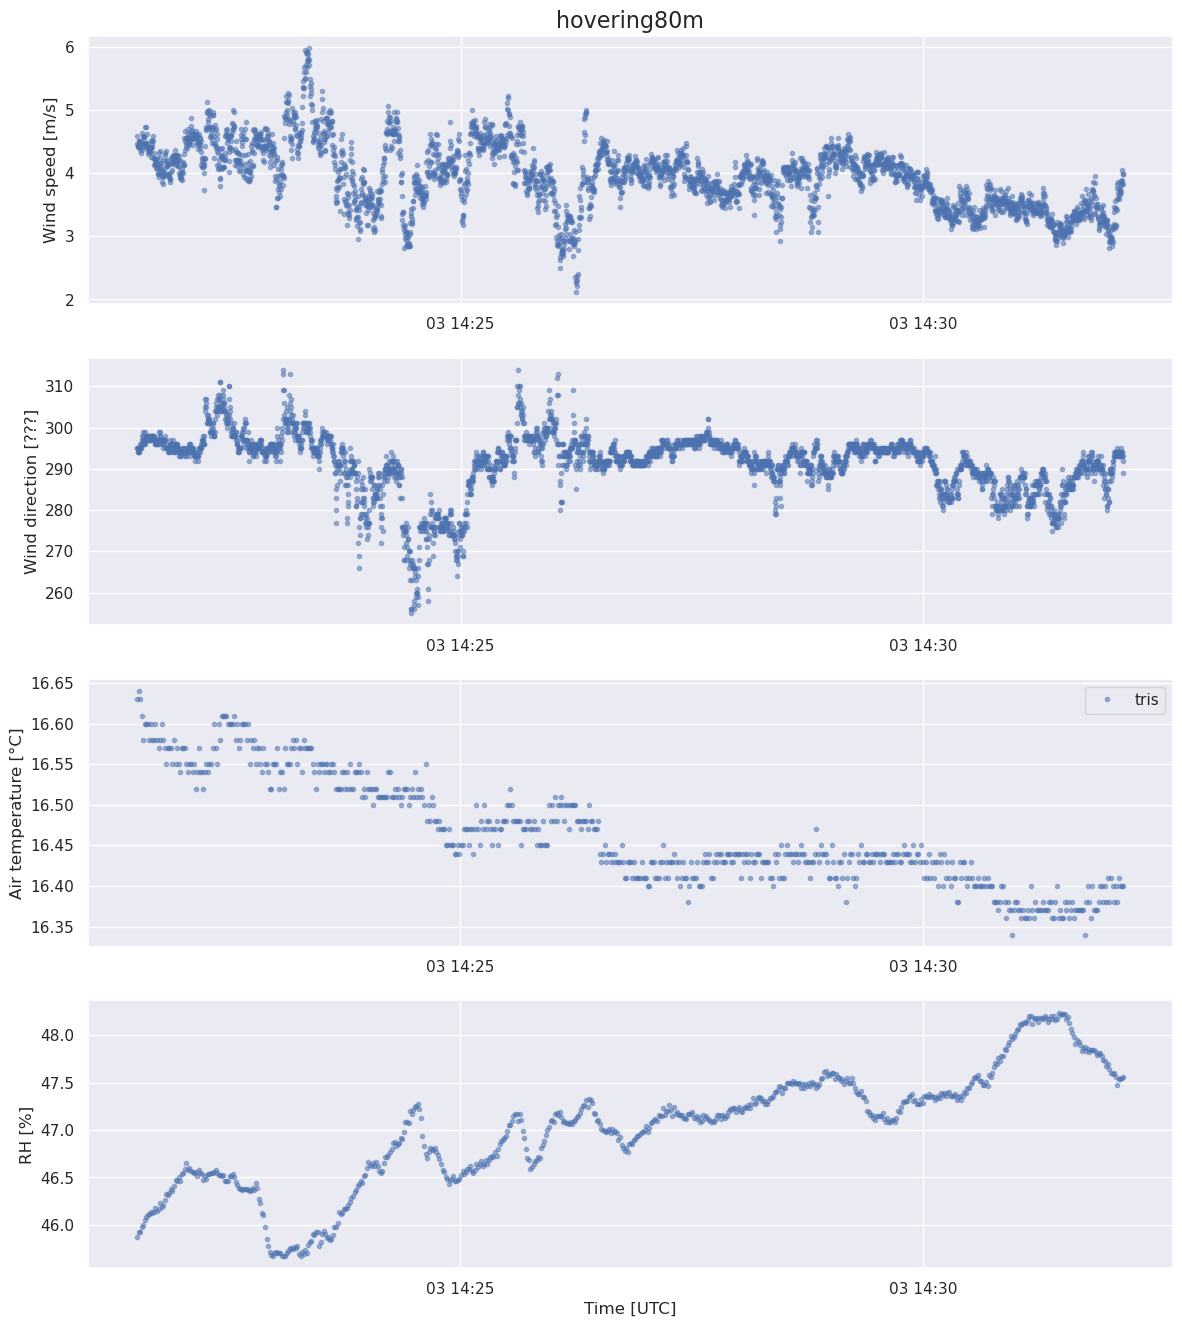

In [110]:
# Plot the most relevant variables

fig,ax=plt.subplots(4,1,figsize=(14,16))

plt.xlabel('Time [UTC]')

ax[0].set_title(label_title,fontsize=16)
ax[0].set_ylabel('Wind speed [m/s]')
ax[0].plot(df_subset_tris['Time (UTC) dt'],df_subset_tris['C.wspd'],'.',alpha=.5)

ax[1].set_ylabel('Wind direction [???]')
ax[1].plot(df_subset_tris['Time (UTC) dt'],df_subset_tris['C.wdir'],'.',alpha=.5)

ax[2].set_ylabel('Air temperature [°C]')
ax[2].plot(df_subset_tris['Time (UTC) dt'],df_subset_tris['SKH1_70727633.temp'],'.',label='tris',alpha=.5)
ax[2].plot(df_subset_imet['Time (UTC) dt'],df_subset_imet['XQ-iMet-XQ Air Temperature'],'.',label='imet',alpha=.5)
ax[2].legend()

ax[3].set_ylabel('RH [%]')
ax[3].plot(df_subset_tris['Time (UTC) dt'],df_subset_tris['SKH1_70727633.rh'],'.',alpha=.5)
ax[3].plot(df_subset_imet['Time (UTC) dt'],df_subset_imet['XQ-iMet-XQ Humidity'],'.',alpha=.5)

plt.savefig('timeseries_'+label_title+'.png',bbox_inches='tight')

Start flight segment 1:2025-11-03T10:34:11.866000000
End flight segment 1:2025-11-03T10:43:24.503000000
---------------------------------------------------------------------
Start flight segment 2:2025-11-03T10:46:35.485000000
End flight segment 2:2025-11-03T10:56:41.907000000
---------------------------------------------------------------------
Start flight segment 3:2025-11-03T10:59:14.487000000
End flight segment 3:2025-11-03T11:11:20.298000000
---------------------------------------------------------------------
Start flight segment 4:2025-11-03T11:11:52.037000000
End flight segment 4:2025-11-03T11:12:12.595000000
---------------------------------------------------------------------
Start flight segment 5:2025-11-03T13:34:32.748000000
End flight segment 5:2025-11-03T13:50:37.282000000
---------------------------------------------------------------------
Start flight segment 6:2025-11-03T14:01:14.842000000
End flight segment 6:2025-11-03T14:13:53.380000000
--------------------------

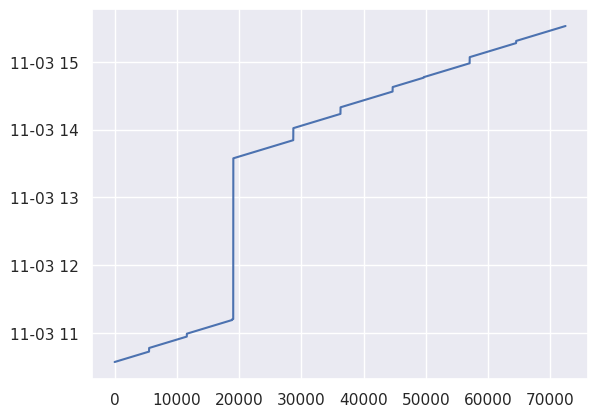

In [12]:
# Have a look at the time deltas between flights, to identify the pauses and the flight segments.

time_values = fr_df['CUSTOM.dateTime_dt'].values
plt.plot(time_values)

delta_t0 = time_values[2]-time_values[1]
fs = 1 # Flight segment

print('Start flight segment '+str(fs)+':'+str(fr_df['CUSTOM.dateTime_dt'].values[0]))
for jj in range(len(fr_df['CUSTOM.dateTime_dt'].values)-1):
    delta_t = time_values[jj+1]-time_values[jj]
    #print(delta_t)
    #print(delta_t.dtype)
    if delta_t>delta_t0*100:
        #print('Index ' + str(jj) + ' - End of flight segment')
        print('End flight segment '+str(fs)+':'+str(fr_df['CUSTOM.dateTime_dt'].values[jj]))
        print('---------------------------------------------------------------------')
        fs += 1
        if jj+1<len(fr_df['CUSTOM.dateTime_dt'].values):
            print('Start flight segment '+str(fs)+':'+str(fr_df['CUSTOM.dateTime_dt'].values[jj+1]))

print('End flight segment '+str(fs)+':'+str(fr_df['CUSTOM.dateTime_dt'].values[jj+1]))